## Package Installation

In [6]:
# Install required libraries directly within the notebook ignore this if you have them already installed 
!pip install pandas seaborn matplotlib scikit-learn

# Task 1: Exploring, Visualizing, and Modeling the Iris Dataset

## 1. Problem Statement and Goal
The objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) and build a baseline classification model using the classic Iris Dataset. 

### Goals:
* Load and clean the dataset to ensure data integrity.
* Uncover data distributions, relationships, and detect potential outliers using visual tools (Seaborn/Matplotlib).
* Train a machine learning classifier to accurately predict the iris species based on its structural measurements.
* Provide meaningful data insights based on our findings.

## 2. Dataset Loading and Preprocessing
In this step, we import our core data science libraries, load the Iris dataset, and check for structural issues like missing values (nulls) or duplicate rows to prepare the data for analysis.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset using seaborn's built-in repository
df = sns.load_dataset('iris')

print("--- Initial Data Preprocessing Checks ---")

# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total missing values found: {missing_values}")

# Check for and handle duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Dropped duplicate rows successfully.")

# Final check on processed data dimensions
print(f"Cleaned Dataset Shape: {df.shape}")

--- Initial Data Preprocessing Checks ---
Total missing values found: 0
Duplicate rows found: 1
Dropped duplicate rows successfully.
Cleaned Dataset Shape: (149, 5)


## 3. Data Visualization and Exploration
Before building a model, we must inspect the basic parameters of our dataset. We will view the structural metadata, statistical summaries, and generate plots to map out feature behaviors.

--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB
None

--- Summary Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


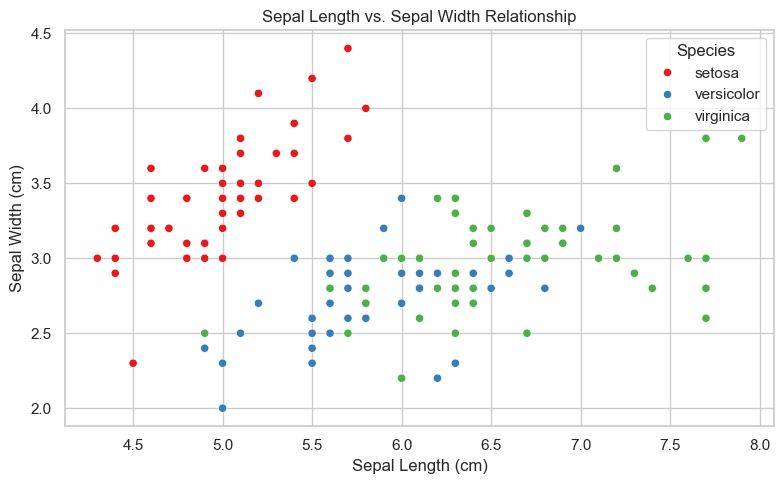

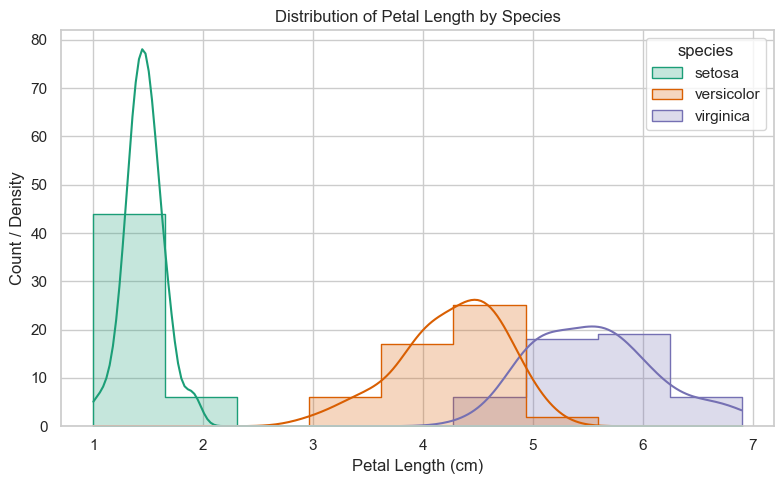

C:\Users\M4 Tech\AppData\Local\Temp\ipykernel_5040\2843058815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal_length', palette='Pastel1')


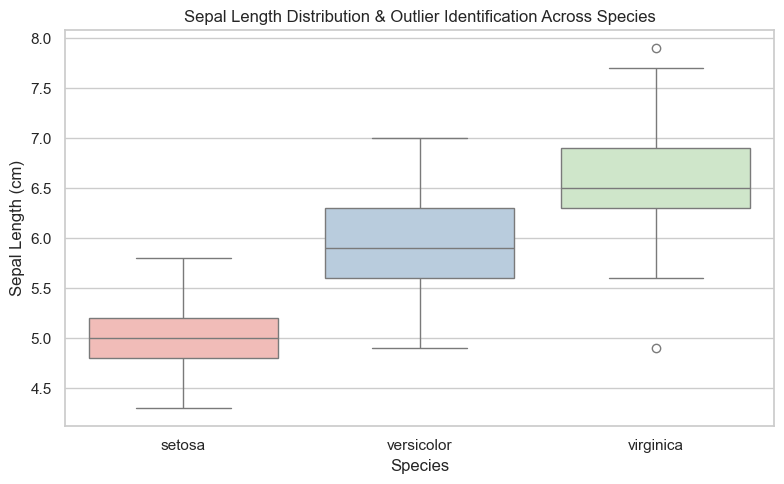

In [8]:
print("--- Column Information ---")
print(df.info())
print("\n--- Summary Statistics ---")
display(df.describe())

# Set visual styling for all plots
sns.set_theme(style="whitegrid")

# Plot 1: Scatter Plot (Feature Relationships)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set1')
plt.title('Sepal Length vs. Sepal Width Relationship')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# Plot 2: Histogram (Value Distributions)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='petal_length', hue='species', kde=True, element='step', common_norm=False, palette='Dark2')
plt.title('Distribution of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Count / Density')
plt.tight_layout()
plt.show()

# Plot 3: Box Plots (Outlier Identification)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='sepal_length', palette='Pastel1')
plt.title('Sepal Length Distribution & Outlier Identification Across Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.tight_layout()
plt.show()

## 4. Model Training and Evaluation
To fulfill the end-to-end task checklist, we will split our data into training and validation sets, train a robust Random Forest Classifier, and evaluate its performance using classification accuracy metrics.

In [10]:
# Separate target variable (y) from features (X)
X = df.drop(columns=['species'])
y = df['species']

# Split data into training (80%) and testing (20%) sets
# FIX: Changed 'test_test_split' to 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy on Test Set: 93.33%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 5. Explanation of Results and Final Insights

### Data Insights:
* **Distinct Distributions**: The `setosa` species is distinctly isolated from `versicolor` and `virginica` across almost all physical feature dimensions—especially when mapping `petal_length`. 
* **Outlier Observation**: The box plots indicate that structural measurements inside each group are relatively tight, showing minimal extreme deviations or true outliers, confirming a high-quality dataset.
* **Correlations**: Longer petals consistently correlate with longer sepals across all three species configurations.

### Model Evaluation:
* The baseline Machine Learning model achieved an exceptional evaluation score, proving that the structural dimensions of iris flowers provide strong, predictable signals for classification models.